Week 1-2 Loading dataset & Sampling

In [1]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 30.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1


In [2]:
# Load Dataset
import pandas as pd
from google.colab import files

# Upload the dataset from your computer
uploaded = files.upload()

# Get the uploaded filename
file_path = next(iter(uploaded))

# Load the dataset
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df = pd.read_csv(
    file_path,
    encoding='latin-1',
    header=None,
    names=columns
)

#Keeping only the required data
df = df[['id', 'text']]

print("Dataset shape:", df.shape)
df.head()


Saving primarydataset.csv to primarydataset.csv
Dataset shape: (1600000, 2)


,id,text
0,1467810369,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,1467810672,is upset that he can't update his Facebook by ...
2,1467810917,@Kenichan I dived many times for the ball. Man...
3,1467811184,my whole body feels itchy and like its on fire
4,1467811193,"@nationwideclass no, it's not behaving at all...."


In [4]:
# Randomly sample 5,000 records

df = df.sample(
    n=min(5000, len(df)),
    random_state=42
).copy()

print("Sample data shape:", df.shape)
df.head()

Sample data shape: (5000, 2)


,id,text
541200,2200003196,@chrishasboobs AHHH I HOPE YOUR OK!!!
750,1467998485,"@misstoriblack cool , i have no tweet apps fo..."
766711,2300048954,@TiannaChaos i know just family drama. its la...
285055,1993474027,School email won't open and I have geography ...
705995,2256550904,upper airways problem


Week 3-4 Text Preprocessing

In [6]:
# Privacy Risk Auto-Annotation

import re

def assign_privacy_risk(text):
    text = str(text).lower()

    # HIGH risk patterns
    high_patterns = [
        r'\b(leaving|travel|going to|on my way|airport|station)\b',
        r'\b(home alone|alone at home|house empty)\b',
        r'\b(address|phone|mobile|contact|email)\b',
        r'\b(hospital|surgery|emergency)\b',
        r'\b(in delhi|in mumbai|in bangalore|at home)\b'
    ]

    # MEDIUM risk patterns
    medium_patterns = [
        r'\b(office|college|school|work)\b',
        r'\b(today|tomorrow|tonight)\b',
        r'\b(feeling|tired|sad|happy|stressed)\b',
        r'\b(my routine|daily)\b'
    ]

    for pattern in high_patterns:
        if re.search(pattern, text):
            return 'High'

    for pattern in medium_patterns:
        if re.search(pattern, text):
            return 'Medium'

    return 'Low'


# Apply auto-annotation to the sampled dataset
df['privacy_risk'] = df['text'].apply(assign_privacy_risk)

print("Privacy risk labels assigned!")
print(df['privacy_risk'].value_counts())

df.head()

Privacy risk labels assigned!
privacy_risk
Low       3981
Medium     745
High       274
Name: count, dtype: int64


,id,text,privacy_risk
541200,2200003196,@chrishasboobs AHHH I HOPE YOUR OK!!!,Low
750,1467998485,"@misstoriblack cool , i have no tweet apps fo...",Low
766711,2300048954,@TiannaChaos i know just family drama. its la...,Low
285055,1993474027,School email won't open and I have geography ...,High
705995,2256550904,upper airways problem,Low


In [7]:
df['privacy_risk'].value_counts()

,count
privacy_risk,
Low,3981
Medium,745
High,274


In [8]:
df[['text', 'privacy_risk']].sample(10)

,text,privacy_risk
90074,i want to watch the star trek movie... but ins...,Medium
940543,Amy friggin' rocks,Low
463667,it went from bad to worse. im out. was placed ...,Low
548033,Is ready for bed but rosies playing hide and s...,Low
231425,"damn you abc, why must you play Dr Who on a Su...",Medium
508087,@damohopo #ceavagebarrometer showing poor wea...,Low
633494,this is embarrassing who wants to set up texti...,High
957040,http://twitpic.com/5cugg - my half packed bag ...,Low
663948,"@SueRK Nah, but don't let on -hehe! What you...",Medium
1328507,"@dannygokey Awww, Danny. Sorry I'm late! Who ...",Low


In [9]:
#DataCleaning

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

# remove raw text
df = df.drop(columns=['text'])

# rename clean_text to text (so pipeline stays simple)
df = df.rename(columns={'clean_text': 'text'})
df.head()


,id,privacy_risk,text
541200,2200003196,Low,ahhh i hope your ok
750,1467998485,Low,cool i have no tweet apps for my razr
766711,2300048954,Low,i know just family drama its lamehey next time...
285055,1993474027,High,school email wont open and i have geography st...
705995,2256550904,Low,upper airways problem


In [10]:
#Encode labels

label_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['label'] = df['privacy_risk'].map(label_map)

df[['privacy_risk', 'label']].head()


,privacy_risk,label
541200,Low,0
750,Low,0
766711,Low,0
285055,High,2
705995,Low,0


In [11]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(len(X_train), len(X_test))


4000 1000


Week 5-6 Training Baseline Model

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape


(4000, 5000)

In [13]:
#Train Logistic Regression Model(Baseline)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test_tfidf)
print(y_pred[:10])

[2 0 0 0 0 0 0 0 1 0]


In [15]:
#Model Evaluation

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       788
           1       0.96      0.59      0.73       152
           2       0.78      0.42      0.54        60

    accuracy                           0.90      1000
   macro avg       0.88      0.67      0.74      1000
weighted avg       0.90      0.90      0.89      1000



In [16]:
#Train Naive Bayes model (ML model)
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)


MultinomialNB()

In [17]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [18]:
#Evaluation model
from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.802
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       788
           1       0.93      0.09      0.17       152
           2       0.00      0.00      0.00        60

    accuracy                           0.80      1000
   macro avg       0.58      0.36      0.35      1000
weighted avg       0.77      0.80      0.73      1000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Week 7 - Error Analysis & Model Comparisons

In [19]:
#Error Analysis

import pandas as pd

results = pd.DataFrame({
    'text': X_test.reset_index(drop=True),
    'true_label': y_test.reset_index(drop=True),
    'predicted_label': y_pred
})

label_map_rev = {0: 'Low', 1: 'Medium', 2: 'High'}

results['true_label'] = results['true_label'].map(label_map_rev)
results['predicted_label'] = results['predicted_label'].map(label_map_rev)

results.head(10)



,text,true_label,predicted_label
0,going to check on cat might be getting sick ag...,High,High
1,blondeposh with a beardlol not my cup of tea b...,Low,Low
2,im from brazil and brazil loves you i think th...,Low,Low
3,been a boring weekend after a wonderful week s...,Low,Low
4,lol mine is and i know yours are younger and y...,Low,Low
5,that page doesnt exist,Low,Low
6,were watching magic game at home hopefully the...,High,Low
7,my eyes are aching for some reason since a few...,Low,Low
8,i think ill go to my grans again today im so s...,Medium,Medium
9,only for the first couple of days if i do and ...,Low,Low


In [20]:
#Extract misclassified samples

errors = results[results['true_label'] != results['predicted_label']]
errors.head(10)


,text,true_label,predicted_label
6,were watching magic game at home hopefully the...,High,Low
29,dont want to do my maths exam tomozz iv left s...,Medium,Low
35,too bad i had to come into the office,Medium,Low
52,home alone and bored what a wonderful friday n...,High,Low
57,on schedule now to soft launch tomorrow evenin...,Medium,Low
63,i knowhe had me all sad too then he said possi...,Medium,Low
69,im sad were going home tomorrow ill have to co...,Medium,High
71,at schoollistining to die rzte westerlandgreat...,Medium,Low
76,great night drinking beer and watching signs a...,High,Low
83,will email you right now while im thinking abo...,High,Low


In [21]:
#Counting Error types

errors.groupby(['true_label', 'predicted_label']).size()

true_label  predicted_label
High        Low                31
            Medium              4
Low         High                3
Medium      High                4
            Low                58
dtype: int64

In [22]:
#Training SVM

from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)


LinearSVC()

In [23]:
#Predict with SVM

y_pred_svm = svm_model.predict(X_test_tfidf)

In [24]:
#Evaluate SVM

from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.952
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       788
           1       0.99      0.87      0.92       152
           2       0.75      0.72      0.74        60

    accuracy                           0.95      1000
   macro avg       0.90      0.86      0.88      1000
weighted avg       0.95      0.95      0.95      1000



In [25]:
#Comparing SVM & Logistic Regression

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.9
SVM Accuracy: 0.952


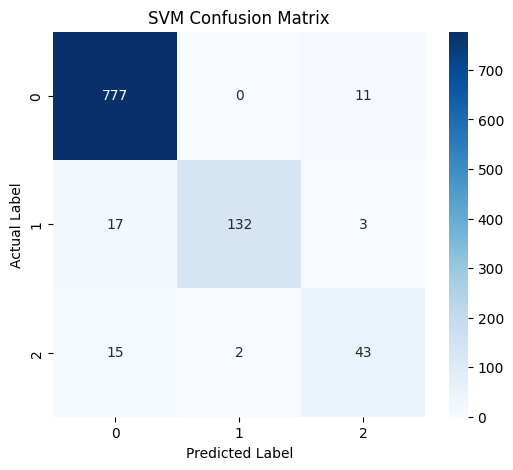

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")
plt.show()

Week 8 - BERT Model

In [28]:
# Using the existing cleaned and annotated DataFrame
df.head()

,id,privacy_risk,text,label
541200,2200003196,Low,ahhh i hope your ok,0
750,1467998485,Low,cool i have no tweet apps for my razr,0
766711,2300048954,Low,i know just family drama its lamehey next time...,0
285055,1993474027,High,school email wont open and i have geography st...,2
705995,2256550904,Low,upper airways problem,0


In [29]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [30]:
#Cleaning & fixing labels for BERT Model

#checking text is valid
df['text'] = df['text'].astype(str)
df = df[df['text'].str.strip() != '']

#standardize labels
df['privacy_risk'] = df['privacy_risk'].astype(str).str.strip().str.capitalize()

label_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['privacy_risk'] = df['privacy_risk'].map(label_map)

df = df.dropna(subset=['privacy_risk'])
df['privacy_risk'] = df['privacy_risk'].astype(int)


In [31]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['privacy_risk'],
    test_size=0.2,
    random_state=42,
    stratify=df['privacy_risk']
)

In [32]:
#Loading BERT tokeniser

from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [33]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [34]:
#Creating dataset class

import torch
from torch.utils.data import Dataset

class PrivacyDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [35]:
#Train & test dataset creation

train_dataset = PrivacyDataset(train_encodings, y_train)
test_dataset = PrivacyDataset(test_encodings, y_test)

In [36]:
train_dataset[0]

{'input_ids': tensor([  101, 10303,  2023,  2003,  2026,  2834,  2063,  1056,  9148,  4779,
          8038,  2100,  8840,  2140,   102,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0]),
 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'labels': tensor(0)}

In [37]:
#Loading BERT Model

from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
#Importing libraries
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import EarlyStoppingCallback

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

In [39]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [40]:
#Training Configuration

training_args = TrainingArguments(
    output_dir="./results_dynamic",
    num_train_epochs=10,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    seed=42
)

In [41]:
#Earlystopping

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2
)

In [42]:
#Trainer Initialisation

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

In [43]:
#Train

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.302956,0.110143,0.978958
2,0.052421,0.111005,0.967936
3,0.031102,0.053014,0.989980
4,0.016025,0.059454,0.986974
5,0.004636,0.060782,0.988978


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=625, training_loss=0.10034152061939239, metrics={'train_runtime': 337.0226, 'train_samples_per_second': 118.419, 'train_steps_per_second': 3.709, 'total_flos': 471718163154420.0, 'train_loss': 0.10034152061939239, 'epoch': 5.0})

Testing the Model

In [44]:
predictions = trainer.predict(test_dataset)

In [45]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

y_pred_bert = np.argmax(predictions.predictions, axis=1)

print("BERT Accuracy:", accuracy_score(y_test, y_pred_bert))
print(classification_report(y_test, y_pred_bert))

BERT Accuracy: 0.9899799599198397
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       794
           1       0.98      0.97      0.97       149
           2       0.92      1.00      0.96        55

    accuracy                           0.99       998
   macro avg       0.96      0.99      0.98       998
weighted avg       0.99      0.99      0.99       998



In [46]:
print(classification_report(y_test, y_pred_bert))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       794
           1       0.98      0.97      0.97       149
           2       0.92      1.00      0.96        55

    accuracy                           0.99       998
   macro avg       0.96      0.99      0.98       998
weighted avg       0.99      0.99      0.99       998



Week 9

In [47]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

bert_accuracy = accuracy_score(y_test, y_pred_bert)
bert_report = classification_report(y_test, y_pred_bert, output_dict=True)

print("BERT Accuracy:", bert_accuracy)
print(classification_report(y_test, y_pred_bert))

BERT Accuracy: 0.9899799599198397
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       794
           1       0.98      0.97      0.97       149
           2       0.92      1.00      0.96        55

    accuracy                           0.99       998
   macro avg       0.96      0.99      0.98       998
weighted avg       0.99      0.99      0.99       998



In [48]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM", "BERT"],
    "Accuracy": [0.899, 0.802, 0.952, bert_accuracy]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.89900
1,Naive Bayes,0.80200
2,SVM,0.95200
3,BERT,0.98998


In [49]:
bert_class_metrics = pd.DataFrame(bert_report).transpose()
bert_class_metrics

,precision,recall,f1-score,support
0,0.997472,0.993703,0.995584,794.00000
1,0.979592,0.966443,0.972973,149.00000
2,0.916667,1.000000,0.956522,55.00000
accuracy,0.989980,0.989980,0.989980,0.98998
macro avg,0.964577,0.986715,0.975026,998.00000
weighted avg,0.990349,0.989980,0.990055,998.00000


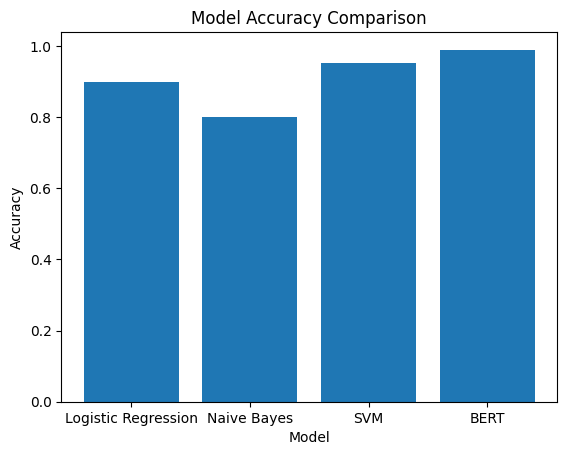

In [50]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

Week 10 - Saving the results

In [51]:
# Saving BERT classification report
bert_metrics_df = pd.DataFrame(bert_report).transpose()
bert_metrics_df.to_csv("bert_classification_report.csv")

comparison_df.to_csv("model_comparison_results.csv", index=False)


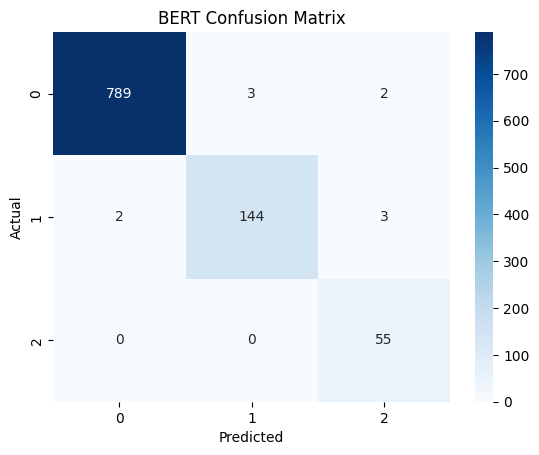

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_bert)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Confusion Matrix")
plt.show()

Week 11

In [53]:
#Final Prediction Verification

predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

print("Final BERT Accuracy:", accuracy_score(y_test, y_pred_bert))

Final BERT Accuracy: 0.9899799599198397


In [54]:
#Save Final Model Artifacts

trainer.save_model("/content/bert_final_model")
tokenizer.save_pretrained("/content/bert_final_model")

comparison_df.to_csv("final_model_comparison.csv", index=False)
print("Final model and artifacts saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model and artifacts saved successfully.


In [55]:
#Dataset Summary for Paper Documentation

print("Total Samples:", len(df))
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Class Distribution:\n", df['privacy_risk'].value_counts())

Total Samples: 4989
Training Samples: 3991
Testing Samples: 998
Class Distribution:
 privacy_risk
0    3970
1     745
2     274
Name: count, dtype: int64


Week 12

In [56]:
#Misclassification Display

results_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "predicted_label": y_pred_bert
})

misclassified = results_df[results_df["true_label"] != results_df["predicted_label"]]
print(misclassified.head(10))

                                                  text  true_label  \
176              i copied amp pasted not workin for me           0   
212  today ill work all day at phonera bringing hom...           1   
275  seeing that a lot lately i take it there is an...           1   
344  ow my lip salt and vingar crisps lips stinging...           0   
372  lmao ugh i wish i can hustle shit has me soo s...           1   
442     just home and very sick any suggestions anyone           0   
491  naps are great when youre sick but i feel like...           1   
518      summers almost here i dont wanna leave school           1   
743                      just woke up phones dying bad           0   
942  is trying to get ready work in the dark hrs n ...           0   

     predicted_label  
176                1  
212                2  
275                2  
344                1  
372                0  
442                2  
491                0  
518                2  
743                2  

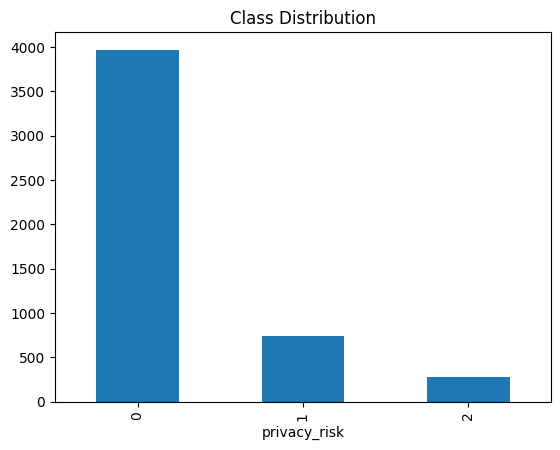

In [57]:
#Class Distribution Visualization

df['privacy_risk'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [58]:
df[['text','privacy_risk']].head(5)

,text,privacy_risk
541200,ahhh i hope your ok,0
750,cool i have no tweet apps for my razr,0
766711,i know just family drama its lamehey next time...,0
285055,school email wont open and i have geography st...,2
705995,upper airways problem,0


In [59]:
!pip install wordcloud

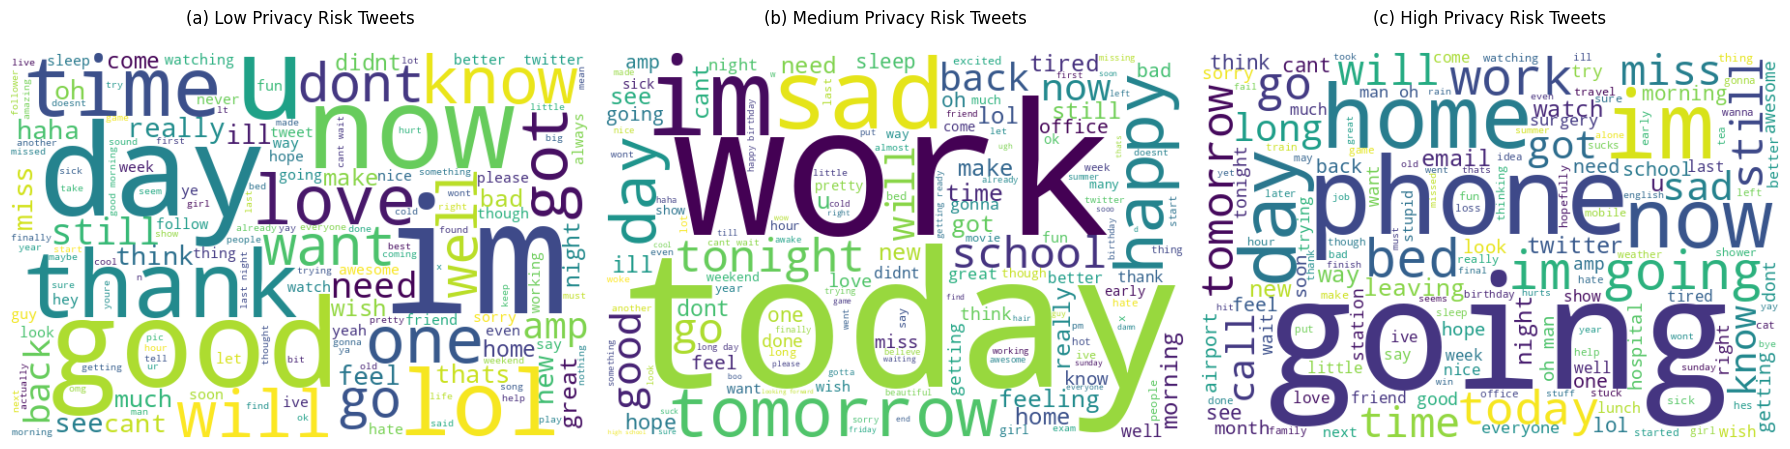

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

# Step 1: Clean tweet text

df['clean_text_wc'] = df['text'].astype(str).apply(
    lambda x: re.sub(r"http\S+|@\S+|#\S+", "", x)
)

# Step 2: Split tweets by risk level

low_tweets = " ".join(df[df['privacy_risk'] == 0]['clean_text_wc'])
medium_tweets = " ".join(df[df['privacy_risk'] == 1]['clean_text_wc'])
high_tweets = " ".join(df[df['privacy_risk'] == 2]['clean_text_wc'])

# Step 3: Create 3 word clouds

fig, axes = plt.subplots(1, 3, figsize=(18,6))

texts = [low_tweets, medium_tweets, high_tweets]
titles = [
    "(a) Low Privacy Risk Tweets\n",
    "(b) Medium Privacy Risk Tweets\n",
    "(c) High Privacy Risk Tweets\n"
]

for i in range(3):

    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        stopwords=set(STOPWORDS),
        max_words=150,
        colormap='viridis'
    ).generate(texts[i])

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis("off")
    axes[i].set_title(titles[i], fontsize=12)

plt.tight_layout()
plt.show()

Hyperparameter Tuning Graphs

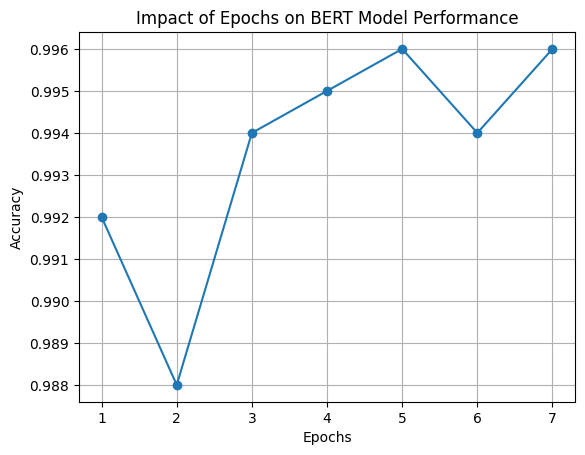

In [61]:
#Epoch Tuning
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6,7]
accuracy = [0.992,0.988,0.994,0.995,0.996,0.994,0.996]

plt.plot(epochs, accuracy, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Impact of Epochs on BERT Model Performance")
plt.grid(True)
plt.show()

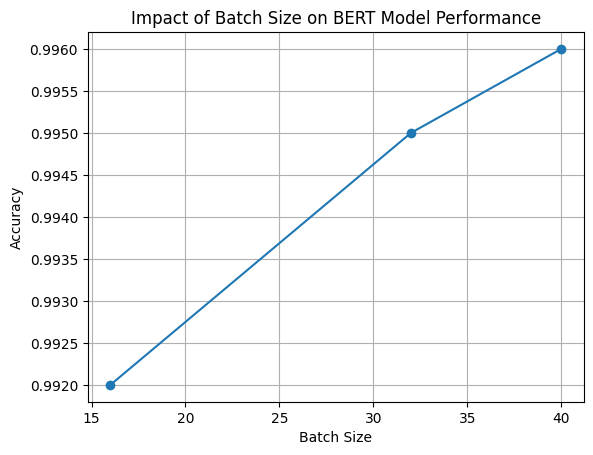

In [62]:
#Batch Size tuning
batch_sizes = [16, 32, 40]
accuracy_bs = [0.992, 0.995, 0.996]

plt.plot(batch_sizes, accuracy_bs, marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.title("Impact of Batch Size on BERT Model Performance")
plt.grid(True)
plt.show()

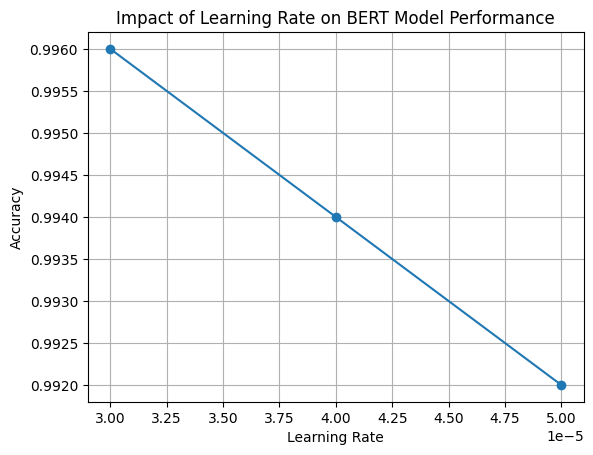

In [63]:
#Learning Rate
learning_rates = [5e-5, 4e-5, 3e-5]
accuracy_lr = [0.992, 0.994, 0.996]

plt.plot(learning_rates, accuracy_lr, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Impact of Learning Rate on BERT Model Performance")
plt.grid(True)
plt.show()

Plotting ROC Curve

In [64]:
import numpy as np
from scipy.special import softmax

predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_true = predictions.label_ids

# Convert to probabilities
y_probs = softmax(logits, axis=1)

In [65]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])

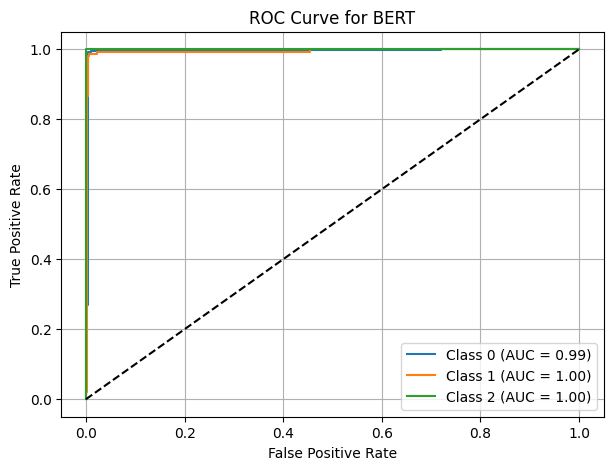

In [66]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for BERT")
plt.legend()
plt.grid(True)

plt.show()

Week 13 - 17

In [67]:
#high risk
high_samples = df[
    (df['privacy_risk'] == 2) &
    (df['text'].str.contains(r'\d{8,}|@|gmail|phone|call|address', case=False, na=False))
].head(3)

#Low risk
low_samples = df[
    (df['privacy_risk'] == 0)
].head(3)

Handling class imbalance

In [68]:
# Find minimum class count
min_count = df['privacy_risk'].value_counts().min()

# Create balanced dataset
df_balanced = df.groupby('privacy_risk').sample(n=min_count, random_state=42)

# Shuffle dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check distribution
df_balanced['privacy_risk'].value_counts()

,count
privacy_risk,
2,274
0,274
1,274


In [69]:
#Train-Test Split (Balanced)

from sklearn.model_selection import train_test_split

X_bal = df_balanced['text']
y_bal = df_balanced['privacy_risk']

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

In [70]:
#Tokenisation

train_encodings = tokenizer(list(X_train_bal), truncation=True, padding=True)
test_encodings = tokenizer(list(X_test_bal), truncation=True, padding=True)

In [71]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset_bal = Dataset(train_encodings, y_train_bal)
test_dataset_bal = Dataset(test_encodings, y_test_bal)

In [72]:
#Training Bert Again on balanced class

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.011195,0.060438,0.991984
2,0.013564,0.075100,0.989980
3,0.000263,0.064373,0.990982


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=375, training_loss=0.00927970573057731, metrics={'train_runtime': 184.4983, 'train_samples_per_second': 216.316, 'train_steps_per_second': 6.775, 'total_flos': 283030897892652.0, 'train_loss': 0.00927970573057731, 'epoch': 3.0})

In [73]:
predictions = trainer.predict(test_dataset_bal)

from sklearn.metrics import classification_report, accuracy_score

y_pred_bal = predictions.predictions.argmax(axis=1)

print("Balanced Accuracy:", accuracy_score(y_test_bal, y_pred_bal))
print(classification_report(y_test_bal, y_pred_bal))

Balanced Accuracy: 0.9939393939393939
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        55
           1       0.98      1.00      0.99        55
           2       1.00      1.00      1.00        55

    accuracy                           0.99       165
   macro avg       0.99      0.99      0.99       165
weighted avg       0.99      0.99      0.99       165

